# 03 — Evaluation & Visualization

Loads the best RL checkpoint, runs argmax inference on the test set, and plots RL vs IL cost across K values.  
**Run `01_setup.ipynb` first** so that `DATA_DIR`, `CLUSTER_DIR`, `RL_SAVE`, etc. are defined.

In [ ]:
import sys, os, json, random
sys.path.insert(0, '..')

%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from tqdm.auto import tqdm

from src.config import DEVICE, MAX_SAFE_PKGS, MAX_SAFE_ULDS
from src.model import TransformerClusterer
from src.data_utils import il_sample_assignment_safe
from src.packer import pd3Packer
from src.reward import compute_packing_cost
from src.train_rl import rl_assign_argmax_safe

# These must be set — either run 01_setup.ipynb or define them here
# DATA_DIR    = '../good_data'
# CLUSTER_DIR = '../clustering_v2'
# IL_WEIGHTS  = os.path.join(CLUSTER_DIR, 'transformer_imitation_v2.pt')
# RL_SAVE     = os.path.join(CLUSTER_DIR, 'transformer_rl_v2_K.pt')

In [ ]:
# Reload RL checkpoint
print('Reading RL checkpoint...')
checkpoint = torch.load(RL_SAVE, map_location=DEVICE)

model = TransformerClusterer().to(DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(f'Best val RL cost at save time: {checkpoint.get("val_rl_cost", float("nan")):.1f}')

# Load fresh IL reference model for a fair comparison baseline
il_ref_model = TransformerClusterer().to(DEVICE)
ckpt_il = torch.load(IL_WEIGHTS, map_location=DEVICE, weights_only=False)
state_il = ckpt_il['model_state_dict'] if isinstance(ckpt_il, dict) and 'model_state_dict' in ckpt_il else ckpt_il
il_ref_model.load_state_dict(state_il)
il_ref_model.eval()
for p in il_ref_model.parameters():
    p.requires_grad_(False)
print('Both models loaded.')

In [ ]:
# Load test data
test_cache = {}
test_meta  = pd.read_csv(os.path.join(DATA_DIR, 'synthetic_test', 'metadata.csv'))
for _, row in test_meta.iterrows():
    tag    = row['instance']
    u_path = os.path.join(DATA_DIR, 'synthetic_test', f'{tag}_ulds.csv')
    p_path = os.path.join(DATA_DIR, 'synthetic_test', f'{tag}_packages.csv')
    if os.path.exists(u_path) and os.path.exists(p_path):
        test_cache[tag] = (pd.read_csv(u_path), pd.read_csv(p_path))
print(f'Loaded {len(test_cache)} test instances.')

# Rebuild the same K-value map used during training
# (if k_values_map_dict isn't in scope from 02_train, rebuild it here)
K_VALUES = [100, 500, 1000, 3000, 5000]
if 'k_values_map_dict' not in dir():
    train_meta_df = pd.read_csv(os.path.join(DATA_DIR, 'synthetic_train', 'metadata.csv'))
    k_values_map_dict = {}
    for meta_df in [train_meta_df, test_meta]:
        instances = meta_df['instance'].tolist()
        random.shuffle(instances)
        per_k = len(instances) // len(K_VALUES)
        for i, k_val in enumerate(K_VALUES):
            for t in instances[i * per_k:(i + 1) * per_k]:
                k_values_map_dict[t] = k_val

current_packer = pd3Packer()

In [ ]:
# Per-instance analysis (RL argmax)
print('Starting RL Model Analysis on Test Instances...\n')

for tag, (ulds_df, pkgs_df) in test_cache.items():
    k_value = k_values_map_dict.get(tag, 0)
    rl_assignment = rl_assign_argmax_safe(model, pkgs_df, ulds_df, DEVICE,
                                          max_pkgs=MAX_SAFE_PKGS, max_ulds=MAX_SAFE_ULDS)
    rl_placements, _ = current_packer.pack(rl_assignment, pkgs_df, ulds_df)
    rl_cost, delay_cost, spread_cost, n_p, unplaced_prio, unplaced_eco = compute_packing_cost(
        rl_placements, pkgs_df, k_value)

    print(f'=== {tag} (K={k_value}) ===')
    print(f'  Total cost : {rl_cost:.2f}  (delay={delay_cost:.2f}, spread={spread_cost:.2f})')
    print(f'  Unplaced   : {len(unplaced_prio)} priority, {len(unplaced_eco)} economy')
    print()

In [ ]:
# RL vs IL comparison — argmax for both models
comparison_results = []
N_IL_EVAL_SAMPLES  = 1

print('Comparing RL (argmax) vs IL (argmax)...')
for tag, (ulds_df, pkgs_df) in tqdm(test_cache.items(), desc='Evaluating'):
    k_value = k_values_map_dict.get(tag, 0)

    rl_assignment = rl_assign_argmax_safe(model, pkgs_df, ulds_df, DEVICE)
    rl_placements, _ = current_packer.pack(rl_assignment, pkgs_df, ulds_df)
    rl_cost, *_ = compute_packing_cost(rl_placements, pkgs_df, k_value)

    il_assignment = rl_assign_argmax_safe(il_ref_model, pkgs_df, ulds_df, DEVICE)
    il_placements, _ = current_packer.pack(il_assignment, pkgs_df, ulds_df)
    il_cost, *_ = compute_packing_cost(il_placements, pkgs_df, k_value)

    comparison_results.append({'instance': tag, 'rl_cost': float(rl_cost),
                               'il_cost': float(il_cost), 'K': k_value})

results_df = pd.DataFrame(comparison_results)
display(results_df.groupby('K')[['rl_cost', 'il_cost']].mean())

In [ ]:
# Save detailed packing coordinates
final_test_data = []
for tag, (ulds_df, pkgs_df) in tqdm(test_cache.items(), desc='Generating coordinates'):
    k_value = k_values_map_dict.get(tag, 0)
    rl_assignment = rl_assign_argmax_safe(model, pkgs_df, ulds_df, DEVICE)
    rl_placements, _ = current_packer.pack(rl_assignment, pkgs_df, ulds_df)
    rl_cost, *_ = compute_packing_cost(rl_placements, pkgs_df, k_value)

    il_assignment = rl_assign_argmax_safe(il_ref_model, pkgs_df, ulds_df, DEVICE)
    il_placements, _ = current_packer.pack(il_assignment, pkgs_df, ulds_df)
    il_cost, *_ = compute_packing_cost(il_placements, pkgs_df, k_value)

    final_test_data.append({
        'instance_tag': tag, 'K': k_value,
        'rl_results': {'total_cost': float(rl_cost), 'placements': rl_placements},
        'il_results': {'total_cost': float(il_cost), 'placements': il_placements},
    })

json_output_path = os.path.join(CLUSTER_DIR, 'test_packing_results.json')
with open(json_output_path, 'w') as f:
    json.dump(final_test_data, f, indent=2)
print(f'Saved -> {json_output_path}')

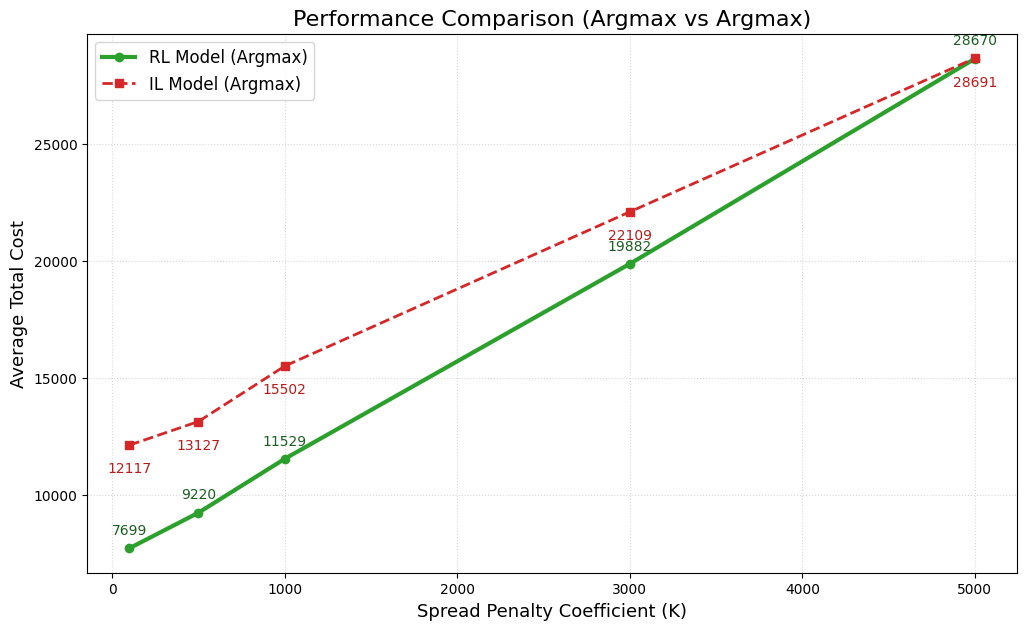

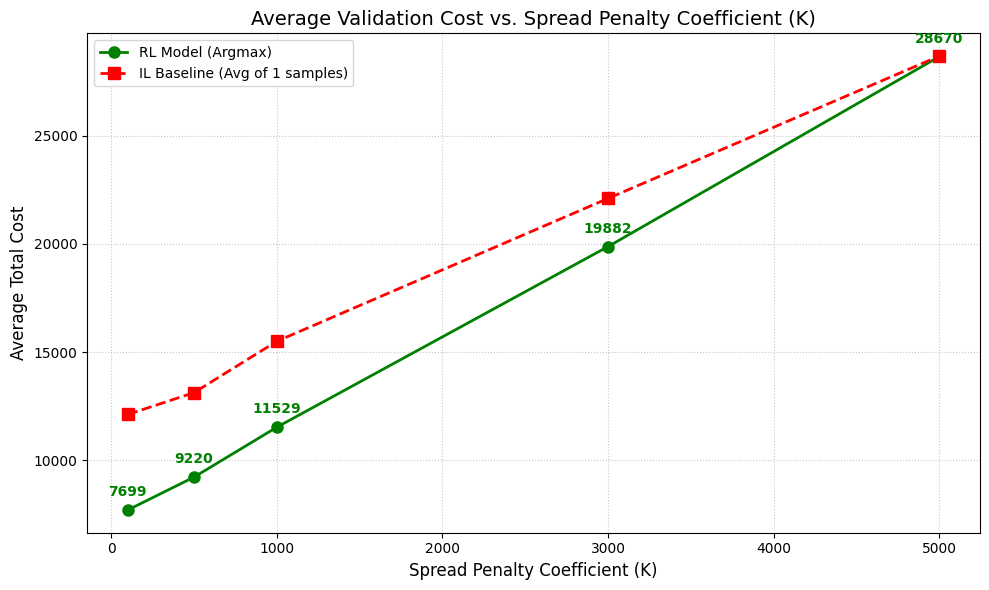

In [1]:
# Plot: RL vs IL average cost per K
k_summary = results_df.groupby('K')[['rl_cost', 'il_cost']].mean().sort_index().reset_index()

plt.figure(figsize=(10, 6))
plt.plot(k_summary['K'], k_summary['rl_cost'], marker='o', color='green',
         label='RL Model (Argmax)', linewidth=2, markersize=8)
plt.plot(k_summary['K'], k_summary['il_cost'], marker='s', color='red',
         label='IL Baseline (Argmax)', linestyle='--', linewidth=2, markersize=8)

for _, row in k_summary.iterrows():
    plt.annotate(f"{row['rl_cost']:.0f}", (row['K'], row['rl_cost']),
                 textcoords='offset points', xytext=(0, 10), ha='center', color='green', weight='bold')

plt.title('Average Validation Cost vs Spread Penalty Coefficient (K)', fontsize=14)
plt.xlabel('Spread Penalty Coefficient (K)', fontsize=12)
plt.ylabel('Average Total Cost', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()